# Digit Recognition Evaluation

End-to-end evaluation of the digit recognition pipeline on held-out test puzzles.
The test set is the 20% of Sudoku dataset puzzles not used during training, as determined
by the puzzle-level split in `DigitRecognition.ipynb`.

**Metrics reported:**
- Grid detection rate
- Overall cell-level digit accuracy
- Per-digit precision, recall, F1
- Confusion matrix
- Per-puzzle digit accuracy distribution
- Perfect puzzle rate
- End-to-end solve rate

In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from utils import normalize_cell, extract_features, parse_dat_file, extract_cells_for_training
from Solver import solveSudoku, isValidSudoku

['5', '3', '.', '.', '7', '.', '.', '.', '.']
['6', '.', '.', '1', '9', '5', '.', '.', '.']
['.', '9', '8', '.', '.', '.', '.', '6', '.']
['8', '.', '.', '.', '6', '.', '.', '.', '3']
['4', '.', '.', '8', '.', '3', '.', '.', '1']
['7', '.', '.', '.', '2', '.', '.', '.', '6']
['.', '6', '.', '.', '.', '.', '2', '8', '.']
['.', '.', '.', '4', '1', '9', '.', '.', '5']
['.', '.', '.', '.', '8', '.', '.', '7', '9']
['5', '3', '4', '6', '7', '8', '9', '1', '2']
['6', '7', '2', '1', '9', '5', '3', '4', '8']
['1', '9', '8', '3', '4', '2', '5', '6', '7']
['8', '5', '9', '7', '6', '1', '4', '2', '3']
['4', '2', '6', '8', '5', '3', '7', '9', '1']
['7', '1', '3', '9', '2', '4', '8', '5', '6']
['9', '6', '1', '5', '3', '7', '2', '8', '4']
['2', '8', '7', '4', '1', '9', '6', '3', '5']
['3', '4', '5', '2', '8', '6', '1', '7', '9']


In [2]:
CELL_SIZE = 40
SUDOKU_DATASET_PATH = os.path.join("data", "sudoku_dataset", "images")

model = joblib.load("models/digit_model.pkl")

with open(os.path.join("data", "test_puzzles.txt")) as f:
    test_files = [line.strip() for line in f if line.strip()]

print(f"Model loaded   : models/digit_model.pkl")
print(f"Test puzzles   : {len(test_files)}")

Model loaded   : models/digit_model.pkl
Test puzzles   : 41


## 1. Run Pipeline on Test Puzzles

In [3]:
all_true = []
all_pred = []
puzzle_results = []

for fname in test_files:
    image_path = os.path.join(SUDOKU_DATASET_PATH, fname)
    dat_path   = image_path.replace(".jpg", ".dat")

    if not os.path.exists(dat_path):
        puzzle_results.append({"fname": fname, "grid_detected": False, "reason": "no dat file"})
        continue

    cells = extract_cells_for_training(image_path, cell_size=CELL_SIZE)
    if cells is None:
        puzzle_results.append({"fname": fname, "grid_detected": False, "reason": "grid not found"})
        continue

    grid = parse_dat_file(dat_path)

    puzzle_true = []
    puzzle_pred = []
    pred_board  = [["." ] * 9 for _ in range(9)]
    true_board  = [["." ] * 9 for _ in range(9)]

    for row in range(9):
        for col in range(9):
            true_digit = grid[row][col]
            if true_digit == 0:
                continue

            true_board[row][col] = str(true_digit)

            cell_img = normalize_cell(cells[row * 9 + col])
            if cell_img.max() == 0:
                continue  # normalization failed — treat as unrecognized

            pred_digit = int(model.predict(extract_features([cell_img]))[0])
            pred_board[row][col] = str(pred_digit)

            puzzle_true.append(true_digit)
            puzzle_pred.append(pred_digit)
            all_true.append(true_digit)
            all_pred.append(pred_digit)

    n_total   = len(puzzle_true)
    n_correct = sum(t == p for t, p in zip(puzzle_true, puzzle_pred))
    is_perfect = (n_correct == n_total and n_total > 0)

    # End-to-end solve: solve ground truth and predicted boards, compare
    true_solution = [row[:] for row in true_board]
    pred_solution = [row[:] for row in pred_board]

    true_solvable = isValidSudoku(true_board)
    pred_solvable = isValidSudoku(pred_board)

    if true_solvable:
        solveSudoku(true_solution)
    if pred_solvable:
        solveSudoku(pred_solution)

    solved_correctly = (true_solvable and pred_solvable and
                        true_solution == pred_solution)

    puzzle_results.append({
        "fname"          : fname,
        "grid_detected"  : True,
        "n_cells"        : n_total,
        "n_correct"      : n_correct,
        "accuracy"       : n_correct / n_total if n_total > 0 else 0,
        "perfect"        : is_perfect,
        "solved_correctly": solved_correctly,
    })

detected   = [r for r in puzzle_results if r["grid_detected"]]
undetected = [r for r in puzzle_results if not r["grid_detected"]]

print(f"Grid detection rate : {len(detected)}/{len(puzzle_results)} "
      f"({len(detected)/len(puzzle_results)*100:.1f}%)")
print(f"Total cells evaluated: {len(all_true)}")

Grid detection rate : 29/41 (70.7%)
Total cells evaluated: 805


## 2. Cell-Level Metrics

In [4]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)

overall_acc = (all_true == all_pred).mean() * 100
print(f"Overall cell accuracy: {overall_acc:.2f}%\n")
print(classification_report(all_true, all_pred,
                             target_names=[str(d) for d in range(1, 10)]))

Overall cell accuracy: 93.54%

              precision    recall  f1-score   support

           1       0.98      0.97      0.97        92
           2       0.99      0.95      0.97        94
           3       0.88      0.92      0.90       101
           4       0.92      0.97      0.95        89
           5       0.93      0.92      0.92        85
           6       0.93      0.92      0.92        83
           7       1.00      0.99      0.99        89
           8       0.86      0.90      0.88        92
           9       0.96      0.89      0.92        80

    accuracy                           0.94       805
   macro avg       0.94      0.93      0.94       805
weighted avg       0.94      0.94      0.94       805



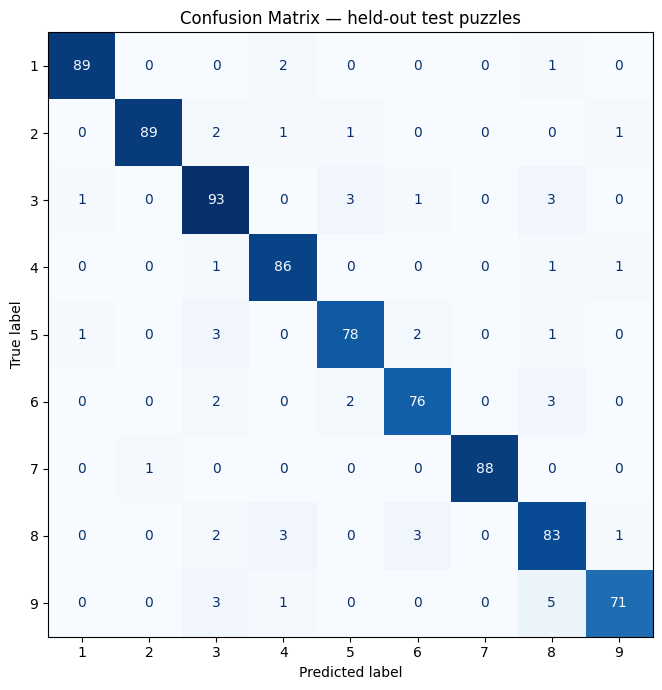

In [5]:
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — held-out test puzzles")
plt.tight_layout()
plt.show()

## 3. Puzzle-Level Metrics

In [6]:
accuracies    = [r["accuracy"] for r in detected]
n_perfect     = sum(r["perfect"] for r in detected)
n_solved      = sum(r["solved_correctly"] for r in detected)

print(f"Per-puzzle digit accuracy : mean={np.mean(accuracies)*100:.1f}%  "
      f"median={np.median(accuracies)*100:.1f}%  "
      f"min={np.min(accuracies)*100:.1f}%")
print(f"Perfect puzzle rate       : {n_perfect}/{len(detected)} "
      f"({n_perfect/len(detected)*100:.1f}%)")
print(f"End-to-end solve rate     : {n_solved}/{len(detected)} "
      f"({n_solved/len(detected)*100:.1f}%)")

Per-puzzle digit accuracy : mean=87.1%  median=96.4%  min=0.0%
Perfect puzzle rate       : 10/29 (34.5%)
End-to-end solve rate     : 10/29 (34.5%)


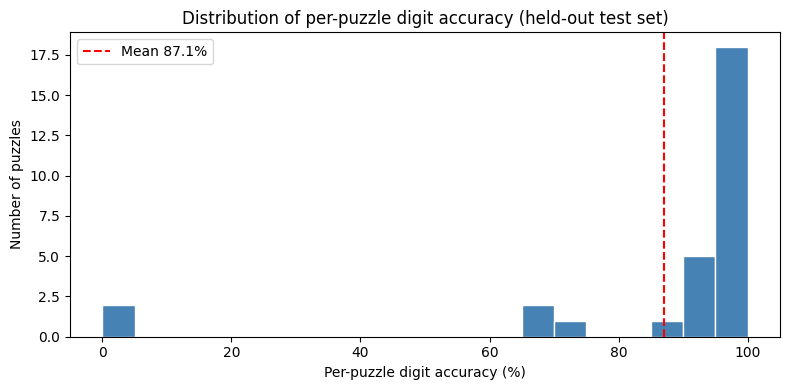

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([a * 100 for a in accuracies], bins=20, range=(0, 100),
        color="steelblue", edgecolor="white")
ax.axvline(np.mean(accuracies) * 100, color="red", linestyle="--",
           label=f"Mean {np.mean(accuracies)*100:.1f}%")
ax.set_xlabel("Per-puzzle digit accuracy (%)")
ax.set_ylabel("Number of puzzles")
ax.set_title("Distribution of per-puzzle digit accuracy (held-out test set)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Summary

In [8]:
print("══════════════════════════════════════════")
print("  Evaluation Summary")
print("══════════════════════════════════════════")
print(f"  Test puzzles             : {len(puzzle_results)}")
print(f"  Grid detection rate      : {len(detected)/len(puzzle_results)*100:.1f}%")
print(f"  Total cells evaluated    : {len(all_true)}")
print(f"  Overall cell accuracy    : {overall_acc:.2f}%")
print(f"  Perfect puzzle rate      : {n_perfect/len(detected)*100:.1f}%")
print(f"  End-to-end solve rate    : {n_solved/len(detected)*100:.1f}%")
print("══════════════════════════════════════════")

══════════════════════════════════════════
  Evaluation Summary
══════════════════════════════════════════
  Test puzzles             : 41
  Grid detection rate      : 70.7%
  Total cells evaluated    : 805
  Overall cell accuracy    : 93.54%
  Perfect puzzle rate      : 34.5%
  End-to-end solve rate    : 34.5%
══════════════════════════════════════════
